# FX TP2/RR2 results

Chapter 4 applies the same forward-moneyness TP2/RR2 tests used for SPX to ten
FX option surfaces. This notebook recreates the reported tables and figures
from saved outputs. It compares:

1. the original FX surfaces at mid-prices and bid-ask prices;
2. where the original violations lie by moneyness and
3. the original surfaces with the L1, L1BA and L1BA-PC repaired surfaces.

The repair names mean:

- **L1:** minimises the absolute price changes needed to remove static
  arbitrage;
- **L1BA:** applies the same repair while accounting for the bid-ask spread;
- **L1BA-PC:** also uses put-call parity and the put-implied synthetic call.

## Running the notebook

This notebook uses the saved CSV files in `outputs/fx` to reproduce the Chapter 4 tables and figures. Running all cells does not rerun the TP2/RR2 tests, rebuild the FX surfaces or modify the saved results. Instructions for rerunning the tests on the supplied FX surfaces are provided in the README.


## 1. Setup

Open this notebook in VS Code or JupyterLab using the `.venv` Python kernel. Run it from the `notebooks/` folder so that:

- `OUT` points to the saved Chapter 4 results;
- `FIGURES` is where the figures are saved.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl


OUT = Path("../outputs/fx")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

pl.Config.set_tbl_cols(20)


polars.config.Config

## 2. Load the saved results

- `original_daily` contains one row per currency-date and test method.
- `original_method` pools all original-surface tests by method.
- `original_moneyness` splits those tests into ITM, crossing-forward and OTM
  regions.
- `repair_method` compares repair methods on their common selected sample.
- `repair_pair` gives the same comparison separately for each currency pair.

The repaired comparison uses only the 158 pair-dates on which a repair was
performed. The original surface is restricted to those same pair-dates, so
the before/after comparison does not mix different samples.


In [3]:
original_daily = pl.read_csv(
    OUT / "fx_original_daily_summary.csv",
    try_parse_dates=True,
)
original_method = pl.read_csv(OUT / "fx_original_method_summary.csv")
original_moneyness = pl.read_csv(OUT / "fx_original_moneyness_summary.csv")

repair_method = pl.read_csv(
    OUT / "fx_repair_comparison_method_summary.csv"
)
repair_pair = pl.read_csv(
    OUT / "fx_repair_comparison_pair_summary.csv"
)

print("Saved FX result tables loaded.")


Saved FX result tables loaded.


## 3. Original FX surfaces

The main test uses cross-maturity strikes rounded to traded strikes. A
`rounded_mid` violation uses mid-prices. A
`rounded_bid_ask_robust` violation must remain after purchases are valued at
the offer and sales at the bid.

The table gives both the number of tested comparisons and the violation rate.


In [3]:
original_table = original_method.with_columns(
    (100 * pl.col("call_violation_rate")).round(4).alias("call_percent"),
    (100 * pl.col("put_violation_rate")).round(4).alias("put_percent"),
)

display(original_table)


run_name,method,number_of_surfaces,call_pairs_tested,call_violations,put_pairs_tested,put_violations,call_violation_rate,put_violation_rate,call_percent,put_percent
str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64
"""rounded_bid_ask_robust""","""original""",17170,5692798,0,5689695,0,0.0,0.0,0.0,0.0
"""rounded_mid""","""original""",17170,5692798,223,5689695,174,0.000039,0.000031,0.0039,0.0031


### Timing of the original violations

The daily counts are pooled by calendar month below. A zero means that no
tested comparison in that month violated. Pooling by month makes the isolated episodes visible without
plotting thousands of daily observations.


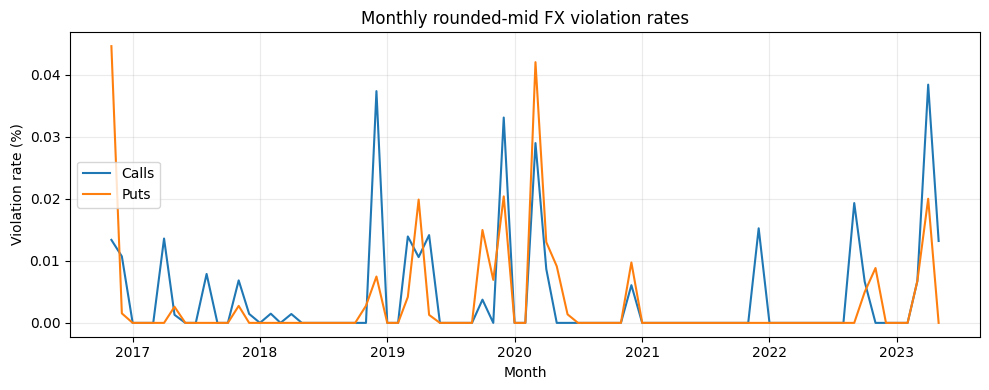

In [4]:
monthly = (
    original_daily
    .filter(pl.col("run_name") == "rounded_mid")
    .with_columns(pl.col("date").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg(
        pl.col("call_pairs_tested").sum(),
        pl.col("call_violations").sum(),
        pl.col("put_pairs_tested").sum(),
        pl.col("put_violations").sum(),
    )
    .sort("month")
    .with_columns(
        (pl.col("call_violations") / pl.col("call_pairs_tested"))
        .alias("call_rate"),
        (pl.col("put_violations") / pl.col("put_pairs_tested"))
        .alias("put_rate"),
    )
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["month"], 100 * monthly["call_rate"], label="Calls")
ax.plot(monthly["month"], 100 * monthly["put_rate"], label="Puts")
ax.set(
    xlabel="Month",
    ylabel="Violation rate (%)",
    title="Monthly rounded-mid FX violation rates",
)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES / "fx_rounded_mid_violation_rates_over_time.png", dpi=150)
plt.show()


### Moneyness of the original violations

The three regions use forward moneyness (k=K/F), which makes strikes
comparable across currency pairs and maturities. Counts are pooled first and
the violation rate is then calculated, so large and small currency samples
are weighted by their number of valid tests.


cp_flag,moneyness_region,pairs_tested,violations,violation_rate
str,str,i64,i64,f64
"""C""","""both_itm""",2196530,0,0.0
"""C""","""both_otm""",1333332,49,0.000037
"""C""","""crosses_forward""",2162936,174,0.00008
"""P""","""both_itm""",1332604,0,0.0
"""P""","""both_otm""",2195516,60,0.000027
"""P""","""crosses_forward""",2161575,114,0.000053


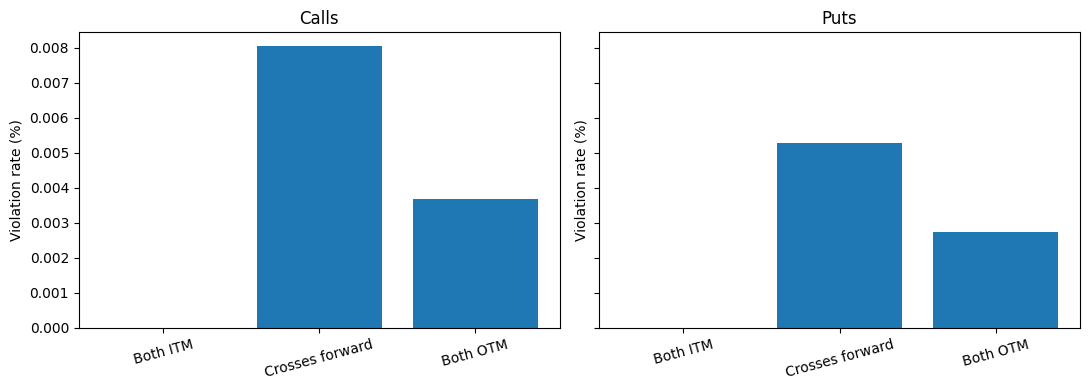

In [5]:
fx_moneyness = (
    original_moneyness
    .filter(pl.col("run_name") == "rounded_mid")
    .group_by("cp_flag", "moneyness_region")
    .agg(
        pl.col("pairs_tested").sum(),
        pl.col("violations").sum(),
    )
    .with_columns(
        (pl.col("violations") / pl.col("pairs_tested"))
        .alias("violation_rate")
    )
    .sort("cp_flag", "moneyness_region")
)
display(fx_moneyness)

moneyness_order = ["both_itm", "crosses_forward", "both_otm"]
moneyness_labels = ["Both ITM", "Crosses forward", "Both OTM"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, option_type, title in zip(axes, ["C", "P"], ["Calls", "Puts"]):
    rows = fx_moneyness.filter(pl.col("cp_flag") == option_type)
    rates = [
        100 * rows.filter(pl.col("moneyness_region") == region)["violation_rate"][0]
        for region in moneyness_order
    ]

    ax.bar(moneyness_labels, rates)
    ax.set(title=title, ylabel="Violation rate (%)")
    ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig(FIGURES / "fx_moneyness_violation_rates.png", dpi=150)
plt.show()


## 4. Repaired FX surfaces

The next table pools the common 158 pair-dates by repair method. The
`original_on_repaired_dates` row is the unrepaired benchmark on exactly the
same observations.

The tests are applied again after repair because removing ordinary static
arbitrage does not mechanically guarantee TP2/RR2.


In [6]:
repair_table = repair_method.with_columns(
    (100 * pl.col("call_violation_rate")).round(4).alias("call_percent"),
    (100 * pl.col("put_violation_rate")).round(4).alias("put_percent"),
)

display(repair_table)


run_name,method,number_of_surfaces,call_pairs_tested,call_violations,put_pairs_tested,put_violations,call_violation_rate,put_violation_rate,call_percent,put_percent
str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64
"""rounded_bid_ask_robust""","""L1""",158,50777,0,0,0,0.0,0.0,0.0,0.0
"""rounded_bid_ask_robust""","""L1BA""",158,50777,0,0,0,0.0,0.0,0.0,0.0
"""rounded_bid_ask_robust""","""L1BA-PC""",158,50777,0,50777,0,0.0,0.0,0.0,0.0
"""rounded_bid_ask_robust""","""original_on_repaired_dates""",158,50777,0,50775,0,0.0,0.0,0.0,0.0
"""rounded_mid""","""L1""",158,50777,36,0,0,0.000709,0.0,0.0709,0.0
"""rounded_mid""","""L1BA""",158,50777,31,0,0,0.000611,0.0,0.0611,0.0
"""rounded_mid""","""L1BA-PC""",158,50777,31,50777,46,0.000611,0.000906,0.0611,0.0906
"""rounded_mid""","""original_on_repaired_dates""",158,50777,223,50775,174,0.004392,0.003427,0.4392,0.3427


### Overall before/after comparison

The bar chart uses the rounded-mid test. Calls and puts are shown separately.


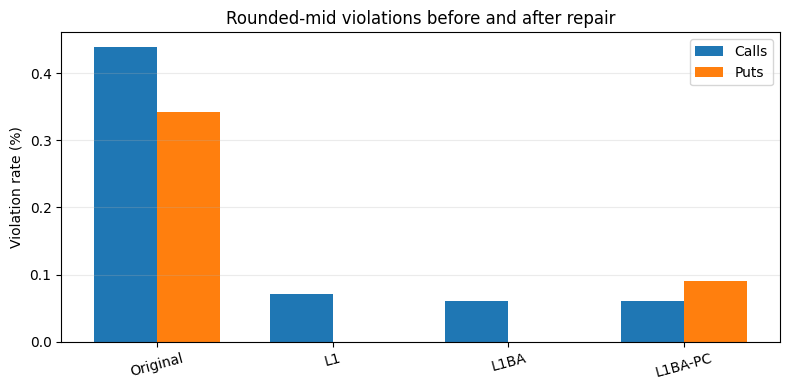

In [7]:
method_order = ["original_on_repaired_dates", "L1", "L1BA", "L1BA-PC"]

mid = (
    repair_method
    .filter(pl.col("run_name") == "rounded_mid")
    .with_columns(
        pl.col("method")
        .replace_strict(method_order, list(range(len(method_order))))
        .alias("plot_order")
    )
    .sort("plot_order")
)

x = np.arange(mid.height)
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - 0.18, 100 * mid["call_violation_rate"], width=0.36, label="Calls")
ax.bar(x + 0.18, 100 * mid["put_violation_rate"], width=0.36, label="Puts")
ax.set_xticks(x, ["Original", "L1", "L1BA", "L1BA-PC"], rotation=15)
ax.set(
    ylabel="Violation rate (%)",
    title="Rounded-mid violations before and after repair",
)
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES / "fx_repair_violation_rates_by_method.png", dpi=150)
plt.show()


### Results by currency pair

The table keeps one row per pair and repair method. The call panel compares
all four methods. The put panel shows the original and L1BA-PC results
because the call-only L1 and L1BA surfaces do not create repaired put prices.


run_name,method,pair,number_of_surfaces,call_pairs_tested,call_violations,put_pairs_tested,put_violations,call_violation_rate,put_violation_rate
str,str,str,i64,i64,i64,i64,i64,f64,f64
"""rounded_mid""","""L1""","""AUDJPY""",29,7590,3,0,0,0.000395,0.0
"""rounded_mid""","""L1""","""AUDUSD""",5,1781,2,0,0,0.001123,0.0
"""rounded_mid""","""L1""","""EURGBP""",18,6767,1,0,0,0.000148,0.0
"""rounded_mid""","""L1""","""EURUSD""",9,3726,3,0,0,0.000805,0.0
"""rounded_mid""","""L1""","""GBPUSD""",19,7141,9,0,0,0.00126,0.0
…,…,…,…,…,…,…,…,…,…
"""rounded_mid""","""original_on_repaired_dates""","""NZDUSD""",4,1343,2,1343,0,0.001489,0.0
"""rounded_mid""","""original_on_repaired_dates""","""USDCAD""",9,3188,3,3188,20,0.000941,0.006274
"""rounded_mid""","""original_on_repaired_dates""","""USDCHF""",20,6572,28,6572,22,0.00426,0.003348


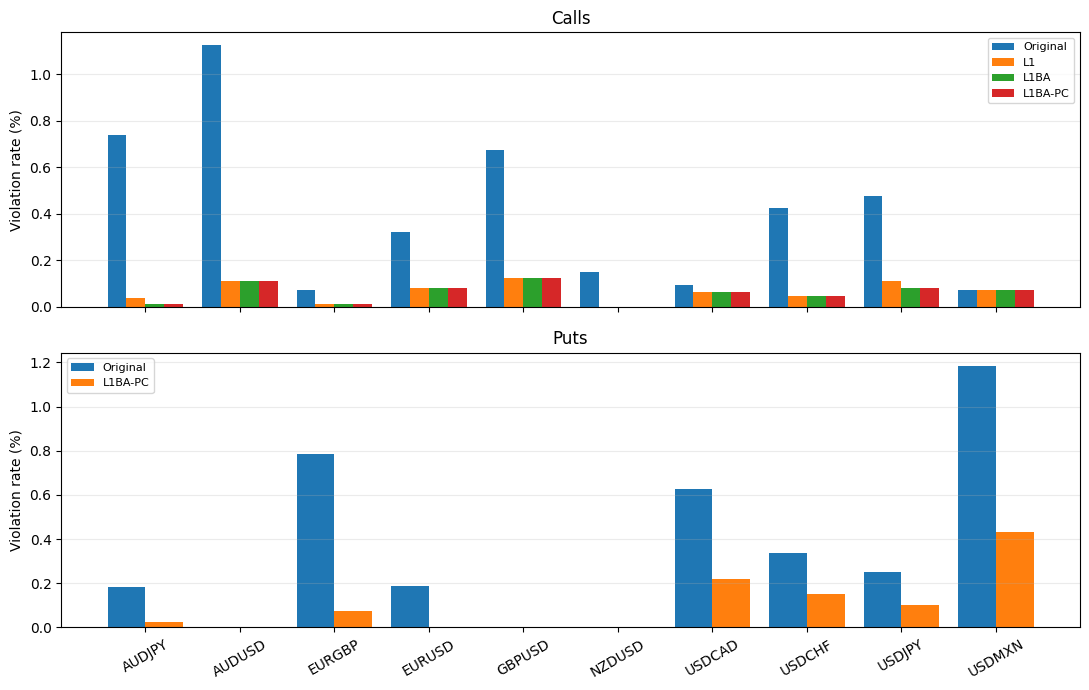

In [8]:
mid_pair = repair_pair.filter(pl.col("run_name") == "rounded_mid")
display(mid_pair)

pairs = sorted(mid_pair["pair"].unique().to_list())
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

panels = [
    (axes[0], "Calls", "call_violation_rate", method_order),
    (
        axes[1],
        "Puts",
        "put_violation_rate",
        ["original_on_repaired_dates", "L1BA-PC"],
    ),
]

for ax, title, rate_column, methods in panels:
    width = 0.8 / len(methods)
    x = np.arange(len(pairs))

    for number, method in enumerate(methods):
        rows = mid_pair.filter(pl.col("method") == method)
        values = [
            100 * rows.filter(pl.col("pair") == pair)[rate_column][0]
            for pair in pairs
        ]
        label = "Original" if method == "original_on_repaired_dates" else method
        offset = (number - (len(methods) - 1) / 2) * width
        ax.bar(x + offset, values, width, label=label)

    ax.set(ylabel="Violation rate (%)", title=title)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8)

axes[1].set_xticks(np.arange(len(pairs)), pairs, rotation=30)
fig.tight_layout()
fig.savefig(FIGURES / "fx_pair_violation_rates_rounded_mid.png", dpi=150)
plt.show()
